# Notebook principal
Este notebook contém o fluxo de pré-processamento, treino e explicações SHAP. Execute as células abaixo em ordem.

# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report,  confusion_matrix
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Lendo o dataset

In [2]:
df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')
df = df[df['Label'] != 2]  

C:\Users\vinic\AppData\Local\Temp\ipykernel_13388\4228867806.py:1: DtypeWarning: Columns (40,53,56,57,58,59,60,61,62,65,66,68,69,70,71,72,73,74,75,76,77,78,79,81,82,83,84,85,87,88,89,90,91,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')


In [3]:
df.columns = [c.lower() for c in df.columns]
print(df.columns.tolist())

['systemtime', 'label', 'name', 'guid', 'eventid', 'version', 'level', 'task', 'opcode', 'keywords', 'eventrecordid', 'correlation', 'execution_processid', 'processid', 'threadid', 'channel', 'computer', 'userid', 'rulename', 'utctime', 'processguid', 'processid', 'image', 'fileversion', 'description', 'product', 'company', 'originalfilename', 'commandline', 'currentdirectory', 'user', 'logonguid', 'logonid', 'terminalsessionid', 'integritylevel', 'hashes', 'parentprocessguid', 'parentprocessid', 'parentimage', 'parentcommandline', 'parentuser', 'protocol', 'initiated', 'sourceisipv6', 'sourceip', 'sourcehostname', 'sourceport', 'sourceportname', 'destinationisipv6', 'destinationip', 'destinationhostname', 'destinationport', 'destinationportname', 'state', 'version2', 'schemaversion', 'configuration', 'configurationfilehash', 'imageloaded', 'signed', 'signature', 'signaturestatus', 'sourceprocessguid', 'sourceprocessid', 'sourcethreadid', 'sourceimage', 'targetprocessguid', 'targetproc

# Começando o treinamento

In [4]:
import sys
sys.path.append('..')
from parser.feature_engineering import extract_behavioral_features

print('Extracting behavioral features...')
df_behavioral = extract_behavioral_features(df)

y = df_behavioral['label']

X = df_behavioral.drop(
    columns=['label', 'process_key'],
    errors='ignore'
)

print('Features:', X.columns.tolist())


2026-05-28 21:46:40,400 - INFO - Starting robust feature engineering


Extracting behavioral features...


c:\Projetos\RansonwareData\Train\..\parser\feature_engineering.py:93: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(


Grouping by: process_guid


2026-05-28 21:47:36,943 - INFO - Extracted features for 13014 processes


Features: ['total_events', 'events_per_sec', 'file_ratio', 'registry_ratio', 'network_ratio', 'dns_ratio', 'burst_ratio', 'file_creation_rate', 'suspicious_ext_ratio', 'suspicious_cmd_ratio', 'unique_extensions_modified', 'child_process_count']


In [5]:
print(X.dtypes)

total_events                    int64
events_per_sec                float64
file_ratio                    float64
registry_ratio                float64
network_ratio                 float64
dns_ratio                     float64
burst_ratio                   float64
file_creation_rate            float64
suspicious_ext_ratio          float64
suspicious_cmd_ratio          float64
unique_extensions_modified      int64
child_process_count             int64
dtype: object


In [6]:
import joblib
import pandas as pd

from sklearn.impute import SimpleImputer

# =====================================
# NUMERIC CONVERSION
# =====================================
for col in X.columns:

    X[col] = pd.to_numeric(
        X[col],
        errors='coerce'
    )

# =====================================
# IMPUTER
# =====================================
imputer = SimpleImputer(
    strategy='constant',
    fill_value=0
)

X_processed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# =====================================
# SAVE PREPROCESSOR
# =====================================
joblib.dump(
    imputer,
    'preprocessor.joblib'
)

print('Preprocessor salvo')

print(df_behavioral.shape)

print(df_behavioral.head())

Preprocessor salvo
(13014, 14)
                              process_key  total_events  events_per_sec  \
0                                       0         32909        0.382779   
1  {00000000-0000-0000-0000-000000000000}           214        0.002721   
2  {27532e6a-012b-61a6-2201-000000001700}            20       20.000000   
3  {27532e6a-012b-61a6-2301-000000001700}            20       20.000000   
4  {27532e6a-012b-61a6-2401-000000001700}            20       20.000000   

   file_ratio  registry_ratio  network_ratio  dns_ratio  burst_ratio  \
0         0.0        0.000334       0.000213   0.000729     0.014586   
1         0.0        0.126168       0.607477   0.247664     0.112150   
2         0.0        0.000000       0.000000   0.000000     0.000000   
3         0.0        0.000000       0.000000   0.000000     0.000000   
4         0.0        0.000000       0.000000   0.000000     0.000000   

   file_creation_rate  suspicious_ext_ratio  suspicious_cmd_ratio  \
0               

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# =====================================
# TRAIN / TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =====================================
# SAVE FEATURE COLUMNS
# =====================================
joblib.dump(
    X_train.columns.tolist(),
    'feature_columns.joblib'
)

# =====================================
# MODEL
# =====================================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# =====================================
# TRAIN
# =====================================
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [8]:
import joblib

joblib.dump(rf, "modelo_ransomware.joblib")

['modelo_ransomware.joblib']

# Testes da IA

In [9]:
prob = rf.predict_proba(X_test)[:, 1]

threshold = 0.3

y_pred = (prob >= threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2509
           1       0.62      0.77      0.68        94

    accuracy                           0.97      2603
   macro avg       0.80      0.87      0.83      2603
weighted avg       0.98      0.97      0.98      2603

[[2464   45]
 [  22   72]]



Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2509
           1       0.62      0.77      0.68        94

    accuracy                           0.97      2603
   macro avg       0.80      0.87      0.83      2603
weighted avg       0.98      0.97      0.98      2603


Confusion Matrix:

[[2464   45]
 [  22   72]]

Accuracy: 0.9743


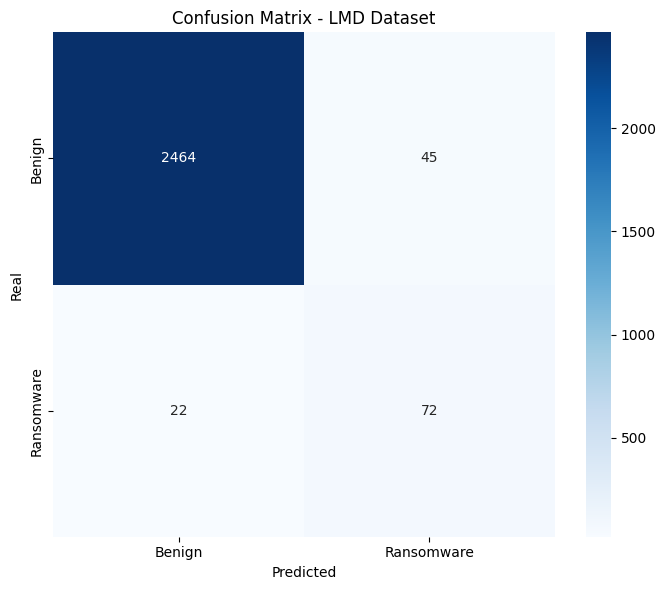

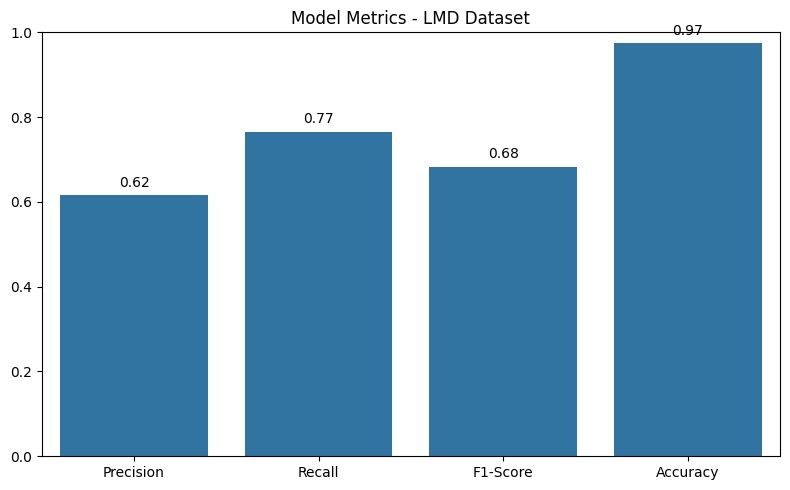

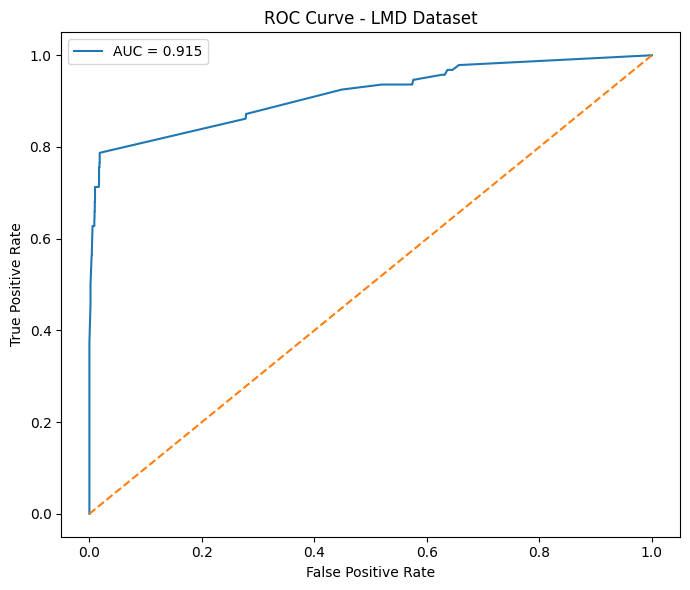

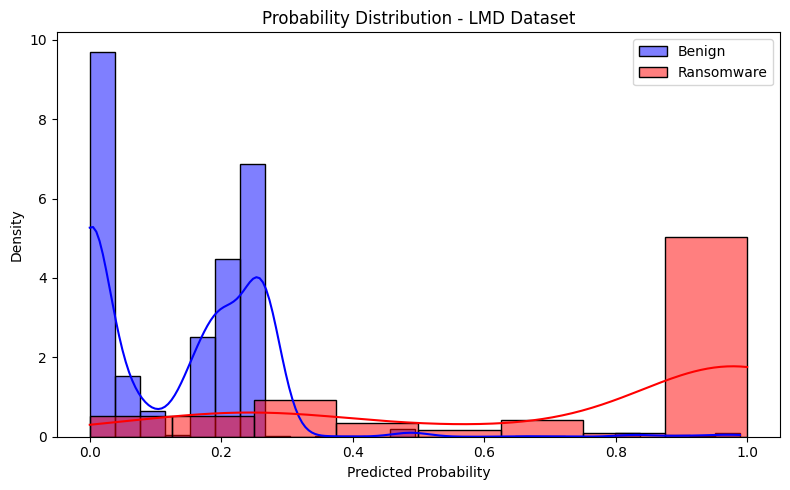

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# =========================================
# PREDICTIONS
# =========================================

prob = rf.predict_proba(X_test)[:, 1]

threshold = 0.30

pred = (prob >= threshold).astype(int)

# =========================================
# METRICS
# =========================================

cm = confusion_matrix(y_test, pred)

precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
acc = accuracy_score(y_test, pred)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred
    )
)

print("\nConfusion Matrix:\n")

print(cm)

print(f"\nAccuracy: {acc:.4f}")

# =========================================
# CONFUSION MATRIX HEATMAP
# =========================================

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Benign',
        'Ransomware'
    ],
    yticklabels=[
        'Benign',
        'Ransomware'
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.title(
    "Confusion Matrix - LMD Dataset"
)

plt.tight_layout()

plt.show()

# =========================================
# METRIC BARPLOT
# =========================================

metrics = {
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Accuracy': acc
}

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

plt.ylim(0,1)

plt.title(
    "Model Metrics - LMD Dataset"
)

for i, v in enumerate(metrics.values()):

    plt.text(
        i,
        v + 0.02,
        f"{v:.2f}",
        ha='center'
    )

plt.tight_layout()

plt.show()

# =========================================
# ROC CURVE
# =========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve - LMD Dataset'
)

plt.legend()

plt.tight_layout()

plt.show()

# =========================================
# PROBABILITY DISTRIBUTION
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    prob[y_test == 0],
    color='blue',
    label='Benign',
    kde=True,
    stat='density'
)

sns.histplot(
    prob[y_test == 1],
    color='red',
    label='Ransomware',
    kde=True,
    stat='density'
)

plt.legend()

plt.title(
    "Probability Distribution - LMD Dataset"
)

plt.xlabel(
    "Predicted Probability"
)

plt.tight_layout()

plt.show()

In [11]:
X_test[:5000]

,total_events,events_per_sec,file_ratio,registry_ratio,network_ratio,dns_ratio,burst_ratio,file_creation_rate,suspicious_ext_ratio,suspicious_cmd_ratio,unique_extensions_modified,child_process_count
12889,331.0,331.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6973,1.0,1.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1343,24.0,24.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
4098,1.0,1.0,0.0,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1901,1.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4358,1.0,1.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
11770,15.0,15.0,0.0,0.933333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
5997,1.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6386,1.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [18]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[
        "Benign",
        "Ransomware"
    ],
    mode="classification"
)

print("LIME explainer criado")


LIME explainer criado


In [19]:
ransom_idx = y_test[y_test == 1].index[0]

print("Índice:", ransom_idx)

Índice: 1674


In [20]:
exp = lime_explainer.explain_instance(
    X_test.loc[ransom_idx].values,
    rf.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)

c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ImportError: cannot import name 'display' from 'IPython.core.display' (c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\IPython\core\display.py)

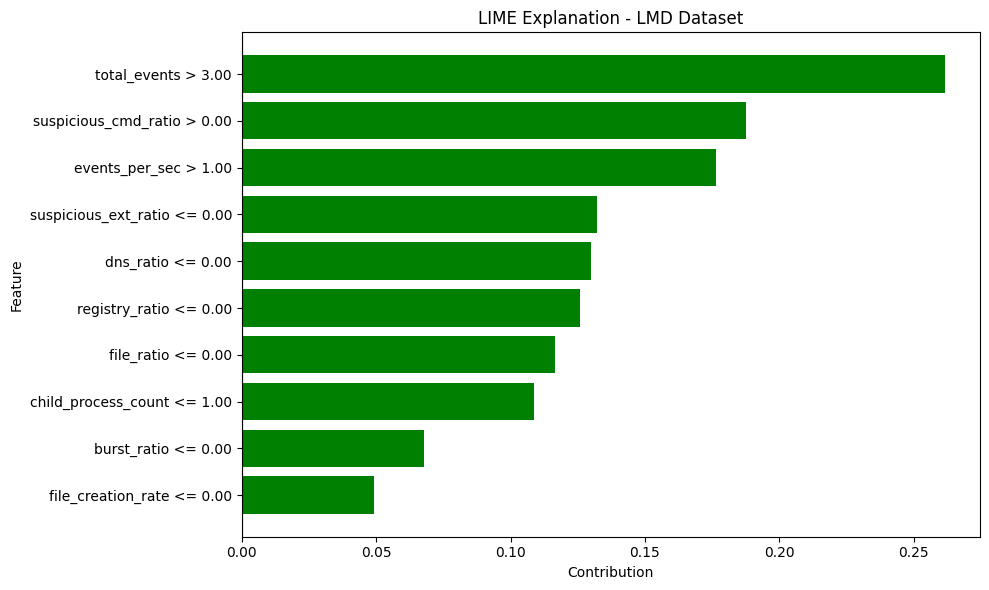

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

lime_df = pd.DataFrame(
    exp.as_list(),
    columns=[
        "feature",
        "contribution"
    ]
)

lime_df = lime_df.sort_values(
    by="contribution"
)

colors = [
    "red" if x < 0 else "green"
    for x in lime_df["contribution"]
]

plt.figure(figsize=(10,6))

plt.barh(
    lime_df["feature"],
    lime_df["contribution"],
    color=colors
)

plt.axvline(
    0,
    color="black"
)

plt.xlabel("Contribution")
plt.ylabel("Feature")

plt.title(
    "LIME Explanation - LMD Dataset"
)

plt.tight_layout()

plt.show()

In [22]:
import shap

shap_explainer = shap.TreeExplainer(rf)

print("SHAP explainer criado")

SHAP explainer criado


In [23]:
shap_values = shap_explainer.shap_values(
    X_test
)

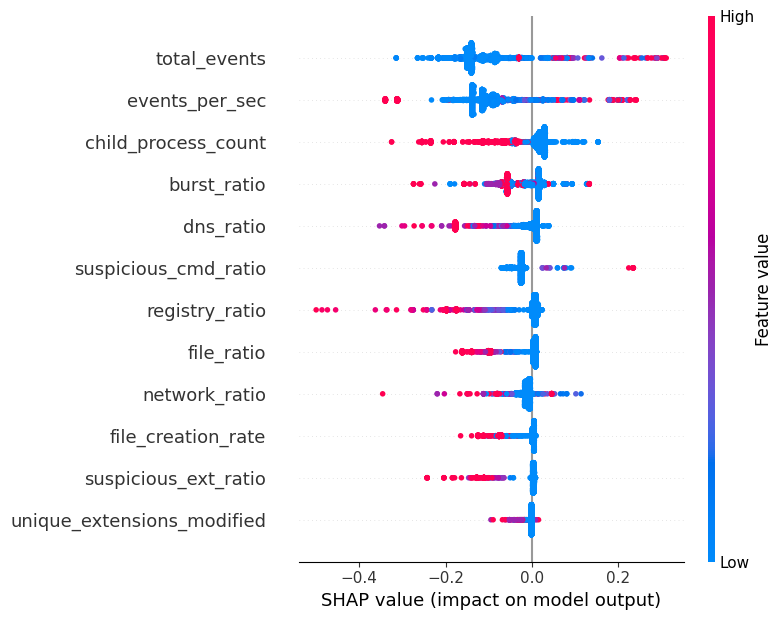

In [24]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

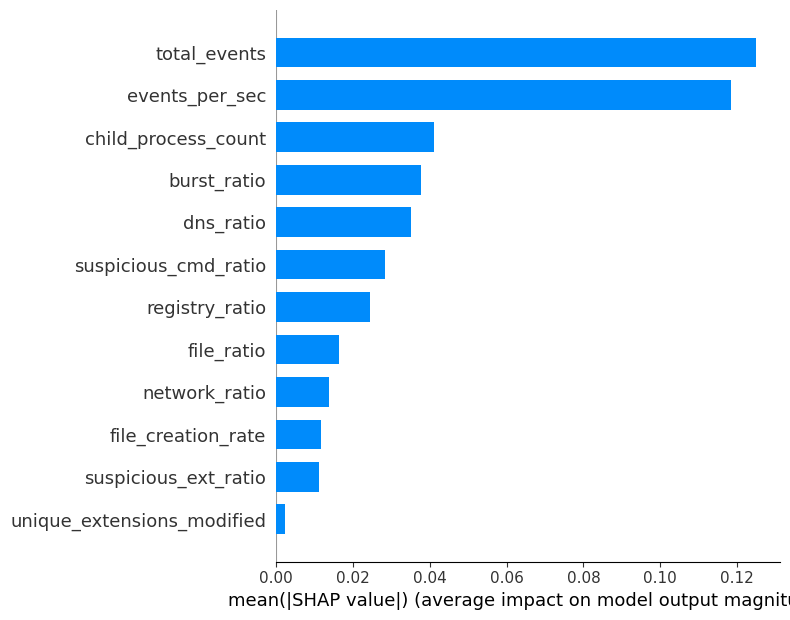

In [25]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

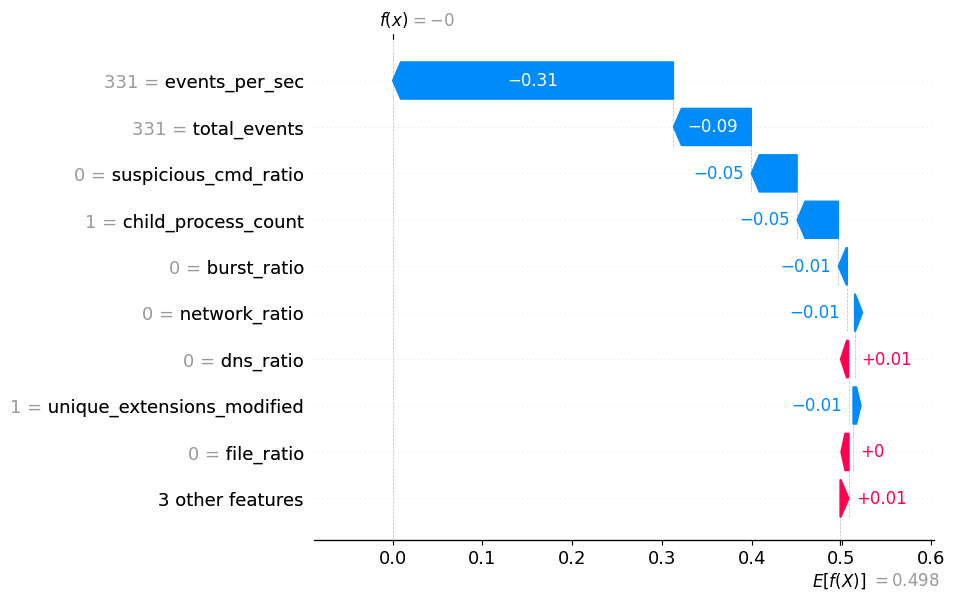

In [26]:
instance_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:, :, 1][instance_idx],
        base_values=shap_explainer.expected_value[1],
        data=X_test.iloc[instance_idx],
        feature_names=X_test.columns
    )
)

In [29]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================
# PREDIÇÕES
# =========================================

threshold = 0.30

prob_dataset = rf.predict_proba(X_test)[:, 1]

pred_dataset = (
    prob_dataset >= threshold
).astype(int)

# =========================================
# MÉTRICAS
# =========================================

cm = confusion_matrix(
    y_test,
    pred_dataset
)

precision = precision_score(
    y_test,
    pred_dataset
)

recall = recall_score(
    y_test,
    pred_dataset
)

f1 = f1_score(
    y_test,
    pred_dataset
)

acc = accuracy_score(
    y_test,
    pred_dataset
)

auc_score = roc_auc_score(
    y_test,
    prob_dataset
)

tn, fp, fn, tp = cm.ravel()

# =========================================
# RESULTADOS
# =========================================

print("=" * 60)
print("DATASET LMD - RESULTADOS")
print("=" * 60)

print(f"\nThreshold: {threshold}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred_dataset
    )
)

print("\nConfusion Matrix:\n")
print(cm)

print("\nMétricas:")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {auc_score:.4f}")

print("\nDetalhamento:")

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# =========================================
# TAXAS IMPORTANTES
# =========================================

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\nTaxas:")

print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")

# =========================================
# PROBABILIDADES
# =========================================

print("\nDistribuição das probabilidades:")

print(
    pd.Series(prob_dataset)
    .describe()
)

# =========================================
# FEATURE IMPORTANCE
# =========================================

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 15 Features:\n")

print(
    importance_df.head(15)
)

DATASET LMD - RESULTADOS

Threshold: 0.3

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2509
           1       0.62      0.77      0.68        94

    accuracy                           0.97      2603
   macro avg       0.80      0.87      0.83      2603
weighted avg       0.98      0.97      0.98      2603


Confusion Matrix:

[[2464   45]
 [  22   72]]

Métricas:
Accuracy : 0.9743
Precision: 0.6154
Recall   : 0.7660
F1-Score : 0.6825
ROC AUC  : 0.9148

Detalhamento:
True Negatives : 2464
False Positives: 45
False Negatives: 22
True Positives : 72

Taxas:
False Positive Rate: 0.0179
False Negative Rate: 0.2340

Distribuição das probabilidades:
count    2603.000000
mean        0.158255
std         0.186709
min         0.000000
25%         0.000000
50%         0.161147
75%         0.261179
max         1.000000
dtype: float64

Top 15 Features:

                       feature  importance
0                 t